In [253]:
import matplotlib.pyplot as plt
import numpy as np

from astropy.visualization import time_support
from astropy.time import Time
import astropy.units as u

from sunpy import timeseries as ts
from sunpy.net import Fido
from sunpy.net import attrs as a

from stixpy.net.client import STIXClient
from stixpy.timeseries import quicklook 
from stixpy.product import Product

import datetime as dt
from sunpy.time import parse_time
from sunpy.time import TimeRange

import pandas as pd

from scipy.signal import find_peaks

In [2]:
flares = pd.read_csv("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/data/STIX_flarelist_w_locations_20210101_20260130_version1_python.csv")

In [3]:
top100 = flares.sort_values("goes_estimated_mean_flux", ascending=False).head(100)

In [19]:
def get_energy_indices(qtable, ranges):
    energy_indices = []
    for e_min, e_max in ranges:
        start_index = np.where(qtable["e_low"] >= e_min)[0][0]
        end_index = np.where(qtable["e_high"] <= e_max)[0][-1]
        energy_indices.append([int(start_index), int(end_index)])
    return energy_indices
    
def get_stix_df(stix_sci, energy_ranges):
    
    energy_indices = get_energy_indices(stix_sci.energies, energy_ranges)
    counts, errors, times, timedeltas, energies = stix_sci.get_data(detector_indices=[[0, 31]],
                                                                    pixel_indices=[[0, 11]],
                                                                    energy_indices=energy_indices,)
    counts = counts.to(u.ct / u.s / u.keV)
    errors = errors.to(u.ct / u.s / u.keV)
    timedeltas = timedeltas.to(u.s)
    
    times = times
    
    energy_columns = [f"{e['e_low']}-{e['e_high']}" for e in energies]
    
    counts_reshaped = counts[:, 0, 0, :]
    
    counts_df = pd.DataFrame(counts_reshaped, index=times.datetime, columns=energy_columns)
    return counts_df

In [21]:
energy_ranges = [(25.0*u.keV, 50*u.keV), (50.0*u.keV, 100*u.keV)]

In [4]:
def rank_overlaps(start, end, sci_query):
    overlaps=[]
    for n in range(len(sci_query[0])):
        latest_start = max(start, sci_query[0][n][0].datetime)
        earliest_end = min(end, sci_query[0][n][1].datetime)
        
        overlap = earliest_end - latest_start
        overlaps.append((overlap.total_seconds(), n))
        
    return np.array(sorted(overlaps, key=lambda x: x[0], reverse=True))

In [45]:
sci_query = Fido.search(a.Time(top100['start_UTC'].iloc[10], top100['end_UTC'].iloc[10]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci,
                        a.stix.DataProduct.sci_xray_spec)
sci_query['stix'].filter_for_latest_version()
sci_query

Start Time,End Time,Instrument,Level,DataType,DataProduct,Ver,Request ID
Time,Time,str4,str2,str3,str13,str3,int64
2023-01-03T02:10:05.000,2023-01-03T08:15:00.000,STIX,L1,SCI,sci-xray-spec,V04,2301033171


In [46]:
sci_files = Fido.fetch(sci_query[0][0])
sci_data = Product(sci_files)

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [50]:
df_test = get_stix_df(sci_data, energy_ranges)
df_test

,25.0 keV-50.0 keV,50.0 keV-100.0 keV
2023-01-03 02:10:05.943,6.720000,2.200000
2023-01-03 02:10:15.193,7.480000,2.206667
2023-01-03 02:10:32.293,7.560494,2.135802
2023-01-03 02:10:40.643,8.800000,2.440000
2023-01-03 02:10:49.093,7.370732,2.246341
...,...,...
2023-01-03 08:14:56.843,7.142857,1.885714
2023-01-03 08:14:57.543,5.942857,2.485714
2023-01-03 08:14:58.243,6.400000,2.371429
2023-01-03 08:14:58.943,7.542857,2.228571


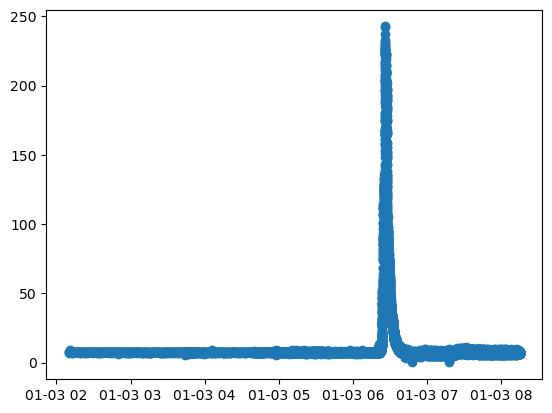

In [48]:
plt.scatter(df_test.index, df_test['25.0 keV-50.0 keV'])

In [49]:
print(df_test.index.freq)

None


In [22]:
df_list=[]
indices=[]
for ind in top100.index:
    sci_query = Fido.search(a.Time(top100['start_UTC'].loc[ind], 
                                   top100['end_UTC'].loc[ind]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci,
                        a.stix.DataProduct.sci_xray_spec)
    sci_query['stix'].filter_for_latest_version()

    start = parse_time(top100['start_UTC'].loc[ind]).datetime
    end = parse_time(top100['end_UTC'].loc[ind]).datetime

    overlaps_ranked = rank_overlaps(start, end, sci_query)
    
    for index in overlaps_ranked[:,1]:
        badrange=False
        sci_files = Fido.fetch(sci_query[0][int(index)])
        sci_data = Product(sci_files)
    
        if sci_data.energies["e_high"][len(sci_data.energies["e_high"])-1]<100*u.keV or sci_data.energies["e_low"][0]>25*u.keV:
            badrange=True
        
        if not badrange:
            sci_df = get_stix_df(sci_data, energy_ranges)
            df_list.append(sci_df)
            indices.append(ind)
            break

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

solo_L1_stix-sci-xray-spec_20240520T022959-20240520T083459_V04_2405209781-50804.fits:   0%|          | 0.00/3.…

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

...

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [23]:
listind100 = top100.index.tolist()
diff = set(listind100)-set(indices)
len(diff)

0

In [28]:
df_list_rs = []
for df in df_list:
    df_resampled = df.resample('s')
    df_list_rs.append(df_resampled)

In [53]:
np.max(df_list[0]['25.0 keV-50.0 keV'])

np.float64(859.9200000000001)

In [29]:
df_list_rs[0]

In [ ]:
df_list_rs.index

In [35]:
df_list_rs = df_list.copy()
for df in df_list_rs:
    df.index = parse_time(df.index).datetime
    df = df.resample('s')

In [37]:
df_list_rs[10]

,25.0 keV-50.0 keV,50.0 keV-100.0 keV
2023-01-03 02:10:05.943,6.720000,2.200000
2023-01-03 02:10:15.193,7.480000,2.206667
2023-01-03 02:10:32.293,7.560494,2.135802
2023-01-03 02:10:40.643,8.800000,2.440000
2023-01-03 02:10:49.093,7.370732,2.246341
...,...,...
2023-01-03 08:14:56.843,7.142857,1.885714
2023-01-03 08:14:57.543,5.942857,2.485714
2023-01-03 08:14:58.243,6.400000,2.371429
2023-01-03 08:14:58.943,7.542857,2.228571


In [60]:
len(indices)

100

In [61]:
top100.index

Index([17678, 16121, 12921, 15873,  8972, 15844, 15798, 17775, 15985,  9007,
        5513, 11949, 15918, 10165, 30536, 19665, 30637, 18238, 10252, 16865,
       16710, 21278, 16752, 18432, 19400, 11730, 15856, 23607, 19491, 15754,
       22906, 12385,  9046,  9008,  8812,  5514,  8973,  2102,  2060,  5639,
        5640, 24372, 22177, 17486, 22548, 12890, 30855, 12903, 30331, 18944,
       15783, 24196, 16647, 18991,  9370, 18433, 16442,  5547,  8974, 30475,
        9668, 30638,  9743, 26858,  6201, 24133, 24342,  8927, 31028, 27709,
       30476,  9100, 16441, 18320, 31580, 16662, 17787,  8717, 17859, 17935,
       15799, 16837,  8745,  8890, 24354, 23889, 17750, 30496, 16352, 18407,
       17633, 22261, 18455, 24215, 23346, 19855, 15986, 24906,  2083,  2130],
      dtype='int64')

In [59]:
indices_array = np.array(indices)
indices_array

array([17678, 16121, 12921, 15873,  8972, 15844, 15798, 17775, 15985,
        9007,  5513, 11949, 15918, 10165, 30536, 19665, 30637, 18238,
       10252, 16865, 16710, 21278, 16752, 18432, 19400, 11730, 15856,
       23607, 19491, 15754, 22906, 12385,  9046,  9008,  8812,  5514,
        8973,  2102,  2060,  5639,  5640, 24372, 22177, 17486, 22548,
       12890, 30855, 12903, 30331, 18944, 15783, 24196, 16647, 18991,
        9370, 18433, 16442,  5547,  8974, 30475,  9668, 30638,  9743,
       26858,  6201, 24133, 24342,  8927, 31028, 27709, 30476,  9100,
       16441, 18320, 31580, 16662, 17787,  8717, 17859, 17935, 15799,
       16837,  8745,  8890, 24354, 23889, 17750, 30496, 16352, 18407,
       17633, 22261, 18455, 24215, 23346, 19855, 15986, 24906,  2083,
        2130])

In [56]:
sci_df = df_list[np.where(indices_array==top100.index[0])[1][0]]

IndexError: tuple index out of range

In [64]:
np.where(indices_array==top100.index[0])[0][0]

np.int64(0)

In [87]:
# fig, axes = plt.subplots(nrows=20, ncols=5, figsize=(15, 50))
# axes = axes.flatten()
# i=0
# for ind in top100.index:
#     ax=axes[i]
#     ax.set_ylabel('ct/(keV s)')
#     ax.xaxis.set_major_locator(plt.MaxNLocator(4))
#     ax.set_title(f"{parse_time(top100['start_UTC'].loc[ind]).datetime.year}-{parse_time(top100['start_UTC'].loc[ind]).datetime.month}")
#     if ind in indices:
#         sci_df = df_list[np.where(indices_array==ind)[0][0]]
        
#         start = parse_time(top100['start_UTC'].loc[ind]).datetime
#         end = parse_time(top100['end_UTC'].loc[ind]).datetime
        
#         plot_df = sci_df.truncate(start, end)
            
#         plot_df.index = parse_time(plot_df.index).datetime
        
#         for n in range(len(plot_df.columns)):
#             ax.plot(plot_df.index, plot_df[plot_df.columns[n]], label=plot_df.columns[n])
#     else:
#         ax.plot([0,1],[0,1], color='red')

#     i+=1

# handles, labels = ax.get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=2, fontsize=11)
# fig.subplots_adjust(hspace=1.5)
# fig.subplots_adjust(wspace=0.5)

In [114]:
i=0
for ind in top100.index:
    #ax=axes[i]
    fig, ax = plt.subplots()
    ax.set_ylabel('ct/(keV s)')
    ax.set_title(f"{parse_time(top100['start_UTC'].loc[ind]).datetime.year}-{parse_time(top100['start_UTC'].loc[ind]).datetime.month}")
    sci_df = df_list[np.where(indices_array==ind)[0][0]]
    
    start = parse_time(top100['start_UTC'].loc[ind]).datetime - dt.timedelta(minutes=30)
    end = parse_time(top100['end_UTC'].loc[ind]).datetime  + dt.timedelta(minutes=30)
    
    plot_df = sci_df.truncate(start, end)
        
    plot_df.index = parse_time(plot_df.index).datetime
    
    for n in range(len(plot_df.columns)):
        ax.plot(plot_df.index, plot_df[plot_df.columns[n]], label=plot_df.columns[n])

    plt.axvline(parse_time(top100['peak_UTC'].loc[ind]).datetime, 0, 1, color = 'darkgrey', linestyle = 'dashed', label='Flare List Peak')
    plt.axvline(plot_df.index[plot_df['25.0 keV-50.0 keV'] == np.max(plot_df['25.0 keV-50.0 keV'])][0], 0, 1, color = 'lightblue', linestyle = 'dashed', label='25-50 keV Peak')
    plt.axvline(parse_time(top100['start_UTC'].loc[ind]).datetime, 0, 1, color = 'yellow', linestyle = 'dashed', label='Flare List Start/End')
    plt.axvline(parse_time(top100['end_UTC'].loc[ind]).datetime, 0, 1, color = 'yellow', linestyle = 'dashed')

    plt.axhline(10, 0, 1, color='red', linestyle='dotted')
    
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', fontsize='small')
    fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/top_100_flares_science_data_plot"+str(i)+".png", bbox_inches='tight')

    i+=1
    
plt.close('all')

C:\Users\derva\AppData\Local\Temp\ipykernel_22400\2924820022.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [77]:
sci_query29 = Fido.search(a.Time(top100['start_UTC'].loc[indices[29]], top100['end_UTC'].loc[indices[29]]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci,
                        a.stix.DataProduct.sci_xray_spec)
sci_query29['stix'].filter_for_latest_version()
sci_query29

Start Time,End Time,Instrument,Level,DataType,DataProduct,Ver,Request ID
Time,Time,str4,str2,str3,str13,str3,int64
2024-05-13T20:30:02.000,2024-05-14T02:34:58.000,STIX,L1,SCI,sci-xray-spec,V04,2405131256
2024-05-14T02:29:58.000,2024-05-14T08:34:58.000,STIX,L1,SCI,sci-xray-spec,V04,2405141390


In [76]:
print(top100['start_UTC'].loc[indices[29]], top100['end_UTC'].loc[indices[29]])

2024-05-14T02:01:28.090 2024-05-14T03:03:52.097


In [78]:
sci_query26 = Fido.search(a.Time(top100['start_UTC'].loc[indices[26]], top100['end_UTC'].loc[indices[26]]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci,
                        a.stix.DataProduct.sci_xray_spec)
sci_query26['stix'].filter_for_latest_version()
sci_query26

Start Time,End Time,Instrument,Level,DataType,DataProduct,Ver,Request ID
Time,Time,str4,str2,str3,str13,str3,int64
2024-05-15T08:29:59.000,2024-05-15T14:34:59.000,STIX,L1,SCI,sci-xray-spec,V04,2405156793
2024-05-15T14:29:59.000,2024-05-15T20:34:58.000,STIX,L1,SCI,sci-xray-spec,V04,2405155111


In [79]:
print(top100['start_UTC'].loc[indices[26]], top100['end_UTC'].loc[indices[26]])

2024-05-15T14:19:47.927 2024-05-15T15:08:27.933


In [82]:
sci_query18 = Fido.search(a.Time(top100['start_UTC'].loc[indices[18]], top100['end_UTC'].loc[indices[18]]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci,
                        a.stix.DataProduct.sci_xray_spec)
sci_query18['stix'].filter_for_latest_version()
sci_query18

Start Time,End Time,Instrument,Level,DataType,DataProduct,Ver,Request ID
Time,Time,str4,str2,str3,str13,str3,int64
2023-09-11T16:30:00.000,2023-09-11T22:35:00.000,STIX,L1,SCI,sci-xray-spec,V04,2309118146
2023-09-11T22:30:00.000,2023-09-12T04:35:01.000,STIX,L1,SCI,sci-xray-spec,V04,2309112494


In [81]:
print(top100['start_UTC'].loc[indices[18]], top100['end_UTC'].loc[indices[18]])

2023-09-11T22:13:20.137 2023-09-11T23:36:00.146


In [89]:
sci_query5 = Fido.search(a.Time(top100['start_UTC'].loc[indices[5]], top100['end_UTC'].loc[indices[5]]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci,
                        a.stix.DataProduct.sci_xray_spec)
sci_query5['stix'].filter_for_latest_version()
sci_query5

Start Time,End Time,Instrument,Level,DataType,DataProduct,Ver,Request ID
Time,Time,str4,str2,str3,str13,str3,int64
2024-05-15T02:29:58.000,2024-05-15T08:34:59.000,STIX,L1,SCI,sci-xray-spec,V04,2405153125
2024-05-15T08:29:59.000,2024-05-15T14:34:59.000,STIX,L1,SCI,sci-xray-spec,V04,2405156793


In [84]:
print(top100['start_UTC'].loc[indices[5]], top100['end_UTC'].loc[indices[5]])

2024-05-15T08:10:19.989 2024-05-15T09:30:39.996


In [98]:
sci_files5 = Fido.fetch(sci_query5)
sci_files5 = sorted(sci_files5)


sci_data5_A = Product(sci_files5[0])
sci_data5_B = Product(sci_files5[1])

df_5_A = get_stix_df(sci_data5_A, energy_ranges)
df_5_B = get_stix_df(sci_data5_B, energy_ranges)

combined_df5 = pd.concat([df_5_A, df_5_B])

combined_df5 = combined_df5.sort_index()

df5 = combined_df5[~combined_df5.index.duplicated(keep="first")]
df5

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

,25.0 keV-50.0 keV,50.0 keV-100.0 keV
2024-05-15 02:30:00.650,6.670588,2.182353
2024-05-15 02:30:04.100,7.005714,2.240000
2024-05-15 02:30:07.650,6.666667,2.161111
2024-05-15 02:30:11.300,6.378378,2.010811
2024-05-15 02:30:15.100,6.317949,2.184615
...,...,...
2024-05-15 14:34:54.589,9.000000,1.880000
2024-05-15 14:34:55.589,10.640000,2.080000
2024-05-15 14:34:56.589,10.280000,2.020000
2024-05-15 14:34:57.589,8.840000,2.100000


In [97]:
combined_df5

,25.0 keV-50.0 keV,50.0 keV-100.0 keV
2024-05-15 02:30:00.650,6.670588,2.182353
2024-05-15 02:30:04.100,7.005714,2.240000
2024-05-15 02:30:07.650,6.666667,2.161111
2024-05-15 02:30:11.300,6.378378,2.010811
2024-05-15 02:30:15.100,6.317949,2.184615
...,...,...
2024-05-15 14:34:54.589,9.000000,1.880000
2024-05-15 14:34:55.589,10.640000,2.080000
2024-05-15 14:34:56.589,10.280000,2.020000
2024-05-15 14:34:57.589,8.840000,2.100000


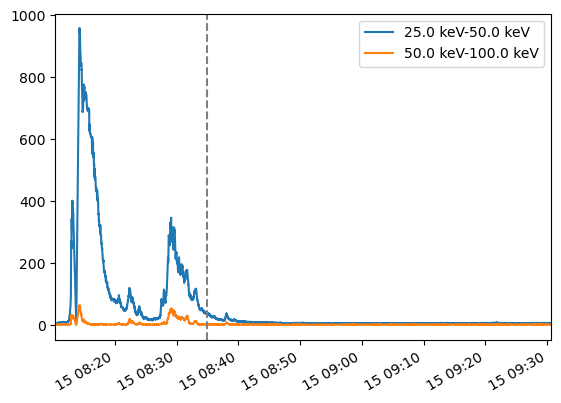

In [101]:
combined_df5.plot()
plt.xlim(parse_time(top100['start_UTC'].loc[indices[5]]).datetime, parse_time(top100['end_UTC'].loc[indices[5]]).datetime)
plt.axvline(parse_time('2024-05-15T08:34:59.000').datetime, 0, 1, color='grey', linestyle='dashed')

In [ ]:
#something like: remove where df.index<dfA.index[last] and >dfB.index[0]

In [85]:
incomplete_file_ind = [5, 18, 26, 29]

In [108]:
for ind in incomplete_file_ind:
    sci_query = Fido.search(a.Time(top100['start_UTC'].iloc[ind], top100['end_UTC'].iloc[ind]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci,
                        a.stix.DataProduct.sci_xray_spec)
    sci_query['stix'].filter_for_latest_version()
    sci_query

    sci_files = Fido.fetch(sci_query)
    sci_files = sorted(sci_files)
    
    
    sci_data_A = Product(sci_files[0])
    sci_data_B = Product(sci_files[1])
    
    df_A = get_stix_df(sci_data_A, energy_ranges)
    df_B = get_stix_df(sci_data_B, energy_ranges)
    
    combined_df = pd.concat([df_A, df_B])
    
    combined_df = combined_df.sort_index()
    
    df = combined_df[~combined_df.index.duplicated(keep="first")]

    df_list[ind]=df


Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

In [107]:
df_list[18]

,25.0 keV-50.0 keV,50.0 keV-100.0 keV
2024-05-15 02:30:00.650,6.670588,2.182353
2024-05-15 02:30:04.100,7.005714,2.240000
2024-05-15 02:30:07.650,6.666667,2.161111
2024-05-15 02:30:11.300,6.378378,2.010811
2024-05-15 02:30:15.100,6.317949,2.184615
...,...,...
2024-05-15 14:34:54.589,9.000000,1.880000
2024-05-15 14:34:55.589,10.640000,2.080000
2024-05-15 14:34:56.589,10.280000,2.020000
2024-05-15 14:34:57.589,8.840000,2.100000


In [113]:
df_list_refined = df_list.copy()

exclude = [33, 35, 36, 55, 56, 58, 59, 61, 70, 80, 83, 90, 96]

for ind in exclude:
    df_list_refined[ind]= 'Excluded'

In [115]:
stix_query69 = Fido.search(a.Time('2025-06-18T04:39:24.385', '2025-06-18T04:48:36.386'), 
                       a.Instrument.stix, 
                       a.stix.DataProduct.ql_lightcurve)

stix_files69 = Fido.fetch(stix_query69)
stix_lc69 = ts.TimeSeries(stix_files69, concatenate=True)
stix_df69 = stix_lc69.to_dataframe()

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [121]:
def t(x):
    return parse_time(x).datetime

(np.float64(20257.17361111111), np.float64(20257.222222222223))

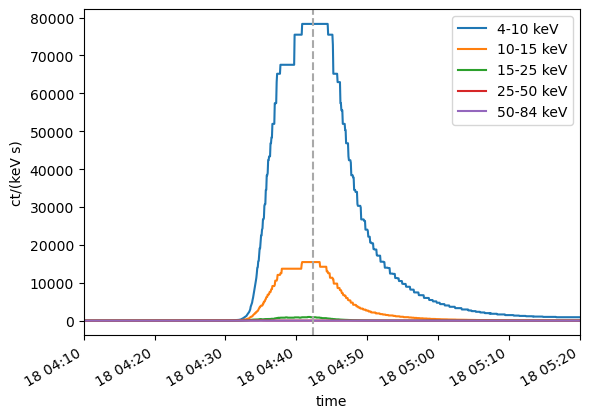

In [125]:
fig, ax = plt.subplots()
ax.set_yscale('linear')
ax.set_ylabel('ct/(keV s)')
stix_df69.plot(ax=ax, y='4-10 keV')
stix_df69.plot(ax=ax, y='10-15 keV')
stix_df69.plot(ax=ax, y='15-25 keV')
stix_df69.plot(ax=ax, y='25-50 keV')
stix_df69.plot(ax=ax, y='50-84 keV')
plt.axvline(parse_time(top100['peak_UTC'].iloc[69]).datetime, 0, 1, color = 'darkgrey', linestyle = 'dashed', label='Peak')
plt.xlim(t('2025-06-18T04:10'), t('2025-06-18T05:20'))

In [136]:
durations = t(flares['end_UTC']) - t(flares['start_UTC'])
list4mean = []
for td in durations:
    td = td.total_seconds()
    list4mean.append(td)
    
np.mean(list4mean)/60

np.float64(20.6231460447526)

In [160]:
flare0 = df_list[0][df_list[0]['25.0 keV-50.0 keV']>10]
tstart0 = flare0.index[0]
tend0 = flare0.index[-1]# better to define t end as NEXT time it drops below 10, not last!!!

In [161]:
print(tstart0, tend0)

2024-07-22 23:47:19.518000 2024-07-23 00:11:06.518000


In [162]:
print(top100['start_UTC'].iloc[0], top100['end_UTC'].iloc[0])

2024-07-22T23:41:53.133 2024-07-23T01:08:49.142


In [163]:
peak0 = df_list[0].index[df_list[0]['25.0 keV-50.0 keV'] == np.max(df_list[0]['25.0 keV-50.0 keV'])][0]

In [165]:
risetime0 = t(peak0)-t(tstart0)
decaytime0 = t(tend0)-t(peak0)

In [166]:
print(risetime0, decaytime0)

0:04:30 0:19:17


In [170]:
i=0
for ind in top100.index:
    #ax=axes[i]
    fig, ax = plt.subplots()
    ax.set_ylabel('ct/(keV s)')
    ax.set_title(f"{parse_time(top100['start_UTC'].loc[ind]).datetime.year}-{parse_time(top100['start_UTC'].loc[ind]).datetime.month}")
    sci_df = df_list[np.where(indices_array==ind)[0][0]]
    
    start = parse_time(top100['start_UTC'].loc[ind]).datetime - dt.timedelta(minutes=30)
    end = parse_time(top100['end_UTC'].loc[ind]).datetime  + dt.timedelta(minutes=30)
    
    plot_df = sci_df.truncate(start, end)
        
    plot_df.index = parse_time(plot_df.index).datetime
    
    for n in range(len(plot_df.columns)):
        ax.plot(plot_df.index, plot_df[plot_df.columns[n]], label=plot_df.columns[n])

    plt.axvline(parse_time(top100['peak_UTC'].loc[ind]).datetime, 0, 1, color = 'darkgrey', linestyle = 'dashed', label='Flare List Peak')
    plt.axvline(plot_df.index[plot_df['25.0 keV-50.0 keV'] == np.max(plot_df['25.0 keV-50.0 keV'])][0], 0, 1, color = 'lightblue', linestyle = 'dashed', label='25-50 keV Peak')
    plt.axvline(parse_time(top100['start_UTC'].loc[ind]).datetime, 0, 1, color = 'yellow', linestyle = 'dashed', label='Flare List Start/End')
    plt.axvline(parse_time(top100['end_UTC'].loc[ind]).datetime, 0, 1, color = 'yellow', linestyle = 'dashed')

    flare = plot_df[plot_df['25.0 keV-50.0 keV']>10]
    tstart = flare.index[0]
    tend = flare.index[-1]

    if t(tend) in plot_df.index:
        plt.axvline(t(tend), 0, 1, color = 'pink', linestyle = 'dotted', label = 'Estimated Start/End')
    if t(tstart) in plot_df.index:
        plt.axvline(t(tstart), 0, 1, color = 'pink', linestyle = 'dotted')
    
    plt.axhline(10, 0, 1, color='red', linestyle='dotted')
    
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', fontsize='small')
    fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/top_100_flares_science_data_plot"+str(i)+".png", bbox_inches='tight')

    i+=1
    
plt.close('all')

C:\Users\derva\AppData\Local\Temp\ipykernel_22400\2089994670.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [236]:
data=np.zeros((87, 6))

In [237]:
stats_df = pd.DataFrame(data, columns = ('flare_list_id', 'peak_counts', 'number_of_peaks', 'rise_time', 'decay_time','comments'))

In [238]:
stats_df['flare_list_id'] = stats_df['flare_list_id'].astype(int)
i=0
label=0
for ind in indices:
    if i not in exclude:
        stats_df.loc[label, 'flare_list_id'] = int(ind)
        label+=1
    i+=1

In [239]:
stats_df['rise_time'] = pd.to_timedelta(stats_df['rise_time'])
stats_df['decay_time'] = pd.to_timedelta(stats_df['decay_time'])

In [254]:
label=0
i=0
for ind in top100.index:
    if i not in exclude:
        sci_df = df_list[np.where(indices_array==ind)[0][0]]
    
        start = parse_time(top100['start_UTC'].loc[ind]).datetime - dt.timedelta(minutes=30)
        end = parse_time(top100['end_UTC'].loc[ind]).datetime  + dt.timedelta(minutes=30)
    
        plot_df = sci_df.truncate(start, end)
        plot_df.index = parse_time(plot_df.index).datetime 
        
        flare = plot_df[plot_df['25.0 keV-50.0 keV']>10]
        tstart = flare.index[0]
        tend = flare.index[-1]

        plot_df.truncate(t(tstart), t(tend))
        peak_counts = np.max(plot_df['25.0 keV-50.0 keV'])
        stats_df.loc[label, 'peak_counts'] = peak_counts

        peak_loc = plot_df.index[plot_df['25.0 keV-50.0 keV'] == peak_counts][0]
        rise_time = peak_loc - tstart
        decay_time = tend - peak_loc
        stats_df.loc[label, 'rise_time'] = rise_time
        stats_df.loc[label, 'decay_time'] = decay_time

        peaks, properties = find_peaks(plot_df['25.0 keV-50.0 keV'], distance=30, prominence=0.1*peak_counts)
        stats_df.loc[label, 'number_of_peaks'] = len(peaks)

        label+=1
    i+=1
        

In [241]:
rise_time

Timedelta('0 days 00:01:26')

In [242]:
np.max(df_list[0]['25.0 keV-50.0 keV'])

np.float64(859.9200000000001)

In [243]:
startends0 = df_list[0]['25.0 keV-50.0 keV']>10
start0 = startends0.index[startends0==True][0]
end0 = startends0.index[(startends0.index>start0) & (startends0==False)][0]
print(start0, end0)

2024-07-22 23:47:19.518000 2024-07-22 23:47:20.518000


In [248]:
stats_df['comments'] = stats_df['comments'].astype(str)

for i in range(87):
    stats_df.loc[i, 'comments'] = ' '

In [249]:
def print_full(x):
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 2000)
    pd.set_option('display.float_format', '{:20,.2f}'.format)
    pd.set_option('display.max_colwidth', None)
    print(x)

In [255]:
print_full(stats_df)

    flare_list_id          peak_counts      number_of_peaks              rise_time             decay_time comments
0           17678               859.92                 4.00        0 days 00:04:30        0 days 00:19:17         
1           16121             4,996.88                 1.00        0 days 00:01:09 0 days 02:09:23.100000         
2           12921               415.68                 2.00        0 days 00:05:21        0 days 00:13:54         
3           15873             1,206.80                 2.00        0 days 00:03:58        0 days 00:10:43         
4            8972               116.64                 9.00        0 days 00:08:55 0 days 01:38:58.800000         
5           15844               957.20                 2.00        0 days 00:02:56 0 days 01:32:30.639000         
6           15798             3,378.96                 2.00        0 days 00:00:53        0 days 00:17:11         
7           17775               413.84                 4.00 0 days 00:28:18.9000